# 卷积神经网络
![卷积神经网络结构](../screen-short/卷积神经网络结构.png)

In [1]:

import sys, os
sys.path.append(os.pardir)
import numpy as np
import pickle
import matplotlib.pyplot as plt

from collections import OrderedDict
from typing import Dict, List
from pydantic import BaseModel

from libs.layers import ConvolutionLayer, ReluLayer, PoolingLayer, AffineLayer, SoftmaxWithLossLayer
from libs.network import Network
from libs.trainer import Trainer

# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [2]:
# 加载数据集
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=False, one_hot_label=True)

print(f"x_train: {x_train.shape}")
print(f"t_train: {t_train.shape}")
print(f"x_test: {x_test.shape}")
print(f"t_test: {t_test.shape}")

save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
x_train: (60000, 1, 28, 28)
t_train: (60000, 10)
x_test: (10000, 1, 28, 28)
t_test: (10000, 10)


In [3]:
class ConveParams(BaseModel):
    """卷积层参数"""
    filter_num: int   # 卷积核数量
    filter_size: int  # 卷积核大小
    stride: int = 1  # 步长
    pad: int = 0  # 填充

class SimpleConvNet(Network):
    """简单的卷积网络实现
    
    网络结构: conv - relu - pool - affine - relu - affine - softmax
    """
    
    def __init__(self, input_dim: tuple, conv_params: ConveParams, hidden_size: int, output_size: int, weight_init_std: float = 0.01):
        """初始化简单的卷积网络

        Args:
            input_dim (tuple): 输入数据的维度，通常为 (通道数, 高, 宽)
            conv_params (ConveParams): 卷积层参数
            hidden_size (int): 隐藏层的神经元数量
            output_size (int): 输出层的神经元数量
            weight_init_std (float): 权重初始化的标准差
        """
        # 提取卷积参数
        filter_num = conv_params.filter_num
        filter_size = conv_params.filter_size
        filter_pad = conv_params.pad
        filter_stride = conv_params.stride
        input_size = input_dim[1]  # 输入图像的高度（假设为正方形）
        
        # 计算卷积层输出尺寸
        conv_output_size = (input_size - filter_size + 2 * filter_pad) / filter_stride + 1
        # 计算池化层输出尺寸（假设池化层使用2x2，步长为2）
        pool_output_size = int(filter_num * (conv_output_size / 2) * (conv_output_size / 2))
        
        # 初始化权重
        self.params = {}
        # 卷积层权重：(滤波器数量, 输入通道数, 滤波器高度, 滤波器宽度)
        self.params['W1'] = weight_init_std * np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        # 第一个全连接层权重
        self.params['W2'] = weight_init_std * np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        # 第二个全连接层权重
        self.params['W3'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)
        
        # 构建网络层
        self.layers = OrderedDict()
        self.layers['Conv1'] = ConvolutionLayer(self.params['W1'], self.params['b1'], 
                                               conv_params.stride, conv_params.pad)
        self.layers['Relu1'] = ReluLayer()
        self.layers['Pool1'] = PoolingLayer(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = AffineLayer(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = ReluLayer()
        self.layers['Affine2'] = AffineLayer(self.params['W3'], self.params['b3'])
        
        # 损失层
        self.last_layer = SoftmaxWithLossLayer()
    
    def predict(self, x: np.ndarray, train_flg: bool = False) -> np.ndarray:
        """前向传播，计算输出
        
        Args:
            x (np.ndarray): 输入数据
            train_flg (bool): 是否处于训练模式
            
        Returns:
            np.ndarray: 网络输出
        """
        for layer in self.layers.values():
            x = layer.forward(x)
        return x
    
    def loss(self, x: np.ndarray, t: np.ndarray, train_flg: bool = False) -> float:
        """计算损失
        
        Args:
            x (np.ndarray): 输入数据
            t (np.ndarray): 监督数据
            train_flg (bool): 是否处于训练模式
            
        Returns:
            float: 损失值
        """
        y = self.predict(x, train_flg)
        return self.last_layer.forward(y, t)
    
    def accuracy(self, x: np.ndarray, t: np.ndarray) -> float:
        """计算准确率
        
        Args:
            x (np.ndarray): 输入数据
            t (np.ndarray): 监督数据
            
        Returns:
            float: 准确率
        """
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1:
            t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    def gradient(self, x: np.ndarray, t: np.ndarray) -> Dict[str, np.ndarray]:
        """计算梯度(反向传播)
        
        Args:
            x (np.ndarray): 输入数据
            t (np.ndarray): 监督数据
            
        Returns:
            Dict[str, np.ndarray]: 各参数的梯度
        """
        # 前向传播
        self.loss(x, t)
        
        # 反向传播
        dout = 1
        dout = self.last_layer.backward(dout)
        
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)
        
        # 设定梯度
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db
        
        return grads
    
    def save_params(self, file_name="simple_cnn_params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="simple_cnn_params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]


In [4]:
cnn = SimpleConvNet(input_dim=(1, 28, 28),
                         conv_params=ConveParams(filter_num=30, filter_size=5, pad=0, stride=1),
                         hidden_size=100,
                         output_size=10)

trainer = Trainer(cnn, x_train, t_train, x_test, t_test,
                  epochs=10, mini_batch_size=100, optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000, verbose=True)


trainer.train()

开始训练...
epoch:1, loss:229.97491970821605, train acc:0.127, test acc:0.135
epoch:2, loss:9.049394558526323, train acc:0.953, test acc:0.962
epoch:3, loss:4.591347190572422, train acc:0.973, test acc:0.972
epoch:4, loss:5.3834971110945515, train acc:0.982, test acc:0.978
epoch:5, loss:4.408511095225753, train acc:0.983, test acc:0.983
epoch:6, loss:0.37737964336256535, train acc:0.985, test acc:0.985
epoch:7, loss:1.1963535605963336, train acc:0.991, test acc:0.988
epoch:8, loss:10.41694968815738, train acc:0.993, test acc:0.986
epoch:9, loss:0.6401640519881102, train acc:0.99, test acc:0.991
epoch:10, loss:0.540672265987471, train acc:0.992, test acc:0.985
=============== Final Test Accuracy ===============
test acc:0.9875


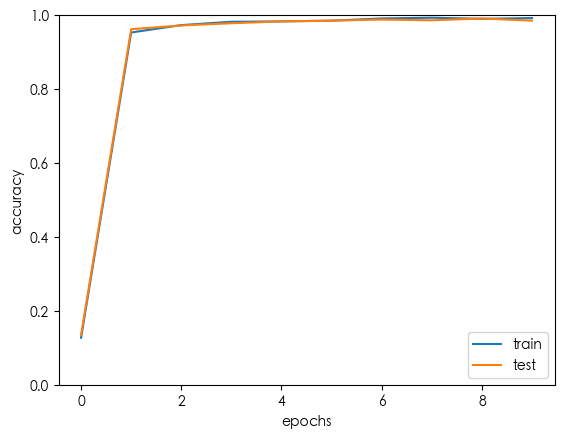

In [5]:
plt.plot(trainer.train_acc_list, label='train', markevery=2)
plt.plot(trainer.test_acc_list, label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [6]:
cnn.save_params("simple_cnn_params.pkl")